# Initialization

In [1]:
from qiskit import QuantumCircuit, transpile, QuantumRegister
from qiskit_aer import AerSimulator, QasmSimulator, Aer
from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options, SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import fake_backend
from qiskit.transpiler import PassManager, passes
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError,
    pauli_error, depolarizing_error, thermal_relaxation_error)
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.qasm2 import dumps

from datetime import datetime
import mysql.connector
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re
import json
import os
import copy
from qiskit.visualization import plot_circuit_layout

from qiskit.converters import circuit_to_dag, dag_to_circuit
import warnings
warnings.filterwarnings("ignore")


CB_color_cycle = ['#1F77B4', '#AEC7E8', '#FF7F0E', '#FFBB78', '#2CA02C', '#98DF8A', '#D62728', '#FF9896',
                  '#9467BD', '#C5B0D5', '#8C564B', '#C49C94', '#E377C2', '#F7B6D2', '#7F7F7F', '#C7C7C7',
                  '#BCBD22', '#DBDB8D', '#17BECF', '#9EDAE5'
                  ]

markers = ['o', 'v', '^', 's', '+', '*', 'x', 'd', '<', '>', 'p']
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':']

# MySQL connection parameters
mysql_config = {
    'user': 'handy',
    'password': 'handy',
    'host': 'ec2-16-170-218-27.eu-north-1.compute.amazonaws.com',
    'database': 'calibration_data'
}

shots = 10000

In [2]:
# import os
# import sys

# module_path = os.path.abspath(os.path.join('..', 'functions'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

# module_path = os.path.abspath(os.path.join('..', 'functions', 'polar_wrapper'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

# from myfunctions import (
#     normalize_counts, used_qubits, neighbours, CNOT_used, neighbours_CNOT_used, 
#     read_benchmark_circuit, count_two_qubit_gates, sum_middle_digits_dict
# )

# from mymultiprog import (
#     avoid_simultaneous_cnot, add_zz_on_simultaneous_cnot, get_initial_layout_from_circuit, 
#     build_idle_coupling_map, multiprogram_compilation_qiskit, merge_circuits
# )
# from mypolar import (
#     divide_half_list, make_polar_qc_based_p1, generate_polar_encoding, \
#     make_polar_qc_based_p2, check_has_zero, generate_polar_encoding_measurement, get_i_position, \
#     polar_code_p2
# )

# from mygraph import create_full_graph, generate_figures

In [3]:
token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")
backend = service.backend("ibm_torino")

qiskit_runtime_service._discover_account:WARNING:2025-11-25 14:02:17,427: Loading account with the given token. A saved account will not be used.


In [4]:
cm = backend.coupling_map


In [5]:
from qiskit.transpiler.passes import SabreSwap
from qiskit.transpiler import PassManagerConfig

from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    Collect2qBlocks,
    ConsolidateBlocks,
    UnitarySynthesis,
)

# Staged Pass Manager

In [6]:
# plugin_manager = PassManagerStagePluginManager()
# basis_gates = pass_manager_config.basis_gates
# coupling_map = pass_manager_config.coupling_map
# initial_layout = pass_manager_config.initial_layout
# init_method = pass_manager_config.init_method or "default"
# layout_method = pass_manager_config.layout_method or "default"
# routing_method = pass_manager_config.routing_method or "default"
# translation_method = pass_manager_config.translation_method or "default"
# scheduling_method = pass_manager_config.scheduling_method
# optimization_method = pass_manager_config.optimization_method or "default"
# scheduling_method = pass_manager_config.scheduling_method or "default"
# target = pass_manager_config.target

## Pass Manager Config

In [7]:
pm_config = PassManagerConfig.from_backend(backend)

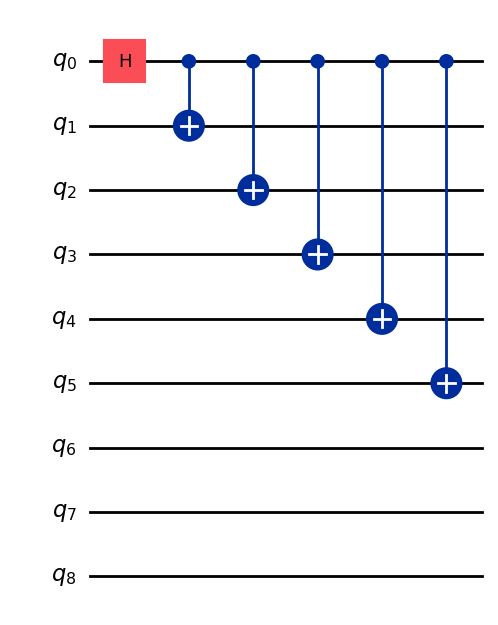

In [8]:
qc = QuantumCircuit(9)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.cx(0,3)
qc.cx(0,4)
qc.cx(0,5)
# qc.cx(0,6)
# qc.cx(0,7)
# qc.cx(0,8)
qc.draw("mpl")

In [32]:
pm_3_exact = generate_preset_pass_manager(
    optimization_level=3, backend=backend, seed_transpiler=12345
)

pm_1_exact = generate_preset_pass_manager(
    optimization_level=1, backend=backend, seed_transpiler=12345
)

pm_0_exact = generate_preset_pass_manager(
    optimization_level=0, backend=backend, seed_transpiler=12345
)

In [10]:
print(dir(pm_3_exact))

['__abstractmethods__', '__add__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_expanded_stages', '_flatten_tasks', '_generate_expanded_stages', '_passmanager_backend', '_passmanager_frontend', '_stages', '_tasks', '_update_passmanager', '_validate_init_kwargs', '_validate_stages', 'append', 'draw', 'expanded_stages', 'init', 'invalid_stage_regex', 'layout', 'max_iteration', 'optimization', 'post_init', 'post_layout', 'post_optimization', 'post_routing', 'post_scheduling', 'post_translation', 'pre_init', 'pre_layout', 'pre_optimization', 'pre_routing', 'pre_scheduling', 'pre_translation', 'property_set', 'rem

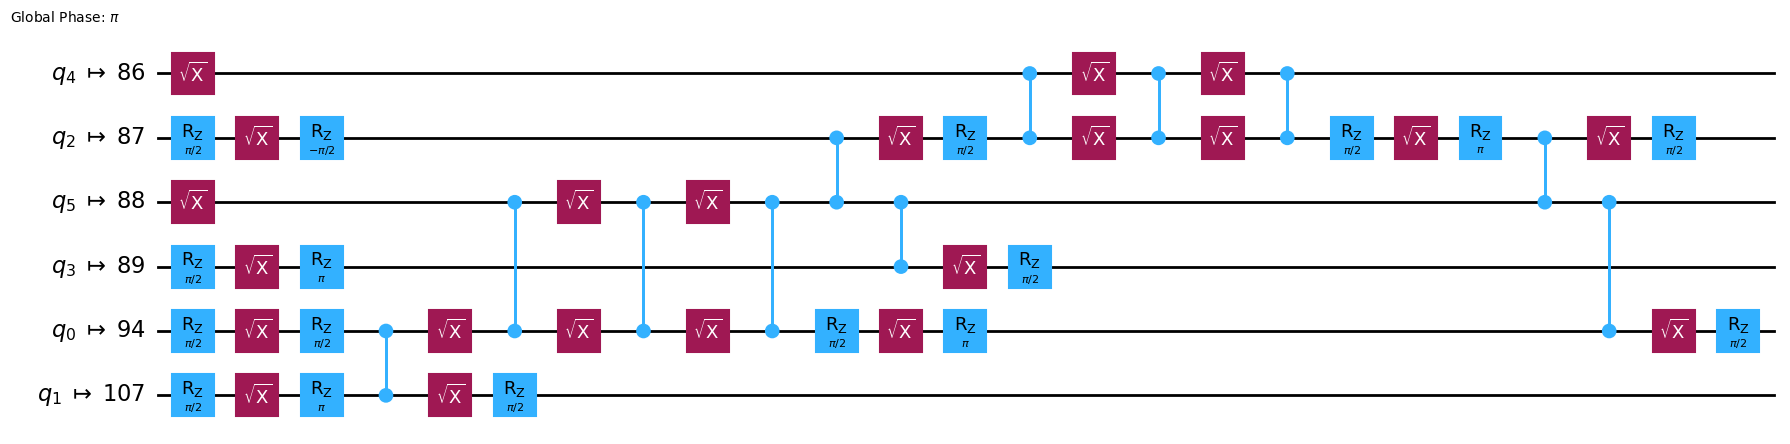

In [11]:
qc_t3 = pm_3_exact.run(qc)
qc_t3.draw("mpl", idle_wires=False, fold=40)

## CM Distance Matrix 

In [13]:
# refresh CM
cm._dist_matrix = None
cm.compute_distance_matrix()

dist_ori = cm.distance_matrix
dist_ori

array([[ 0.,  1.,  2., ..., 25., 25., 25.],
       [ 1.,  0.,  1., ..., 26., 26., 26.],
       [ 2.,  1.,  0., ..., 27., 27., 27.],
       ...,
       [25., 26., 27., ...,  0.,  6., 10.],
       [25., 26., 27., ...,  6.,  0.,  6.],
       [25., 26., 27., ..., 10.,  6.,  0.]])

In [14]:
cm

In [17]:
# update distance matrix
tmp = cm._dist_matrix.copy()
tmp[0][1] = 30
tmp[0][2] = 8
tmp[0][126] = 200
tmp[41][53] = 200
tmp[53][41] = 200
tmp[72][81] = 200
tmp[81][72] = 200
tmp[82][83] = 100
tmp[83][82] = 100

cm._dist_matrix = tmp

In [19]:
updated_cm = cm
updated_cm.distance_matrix

array([[ 0., 30.,  8., ..., 25., 25., 25.],
       [ 1.,  0.,  1., ..., 26., 26., 26.],
       [ 2.,  1.,  0., ..., 27., 27., 27.],
       ...,
       [25., 26., 27., ...,  0.,  6., 10.],
       [25., 26., 27., ...,  6.,  0.,  6.],
       [25., 26., 27., ..., 10.,  6.,  0.]])

## SabreSwap NA

In [20]:
# from qiskit.transpiler import passes
# [pass_ for pass_ in dir(passes) if pass_[0].isupper()]

In [ ]:
from qiskit.transpiler.preset_passmanagers.plugin import list_stage_plugins

In [22]:
list_stage_plugins("routing")

['basic', 'default', 'lookahead', 'none', 'sabre']

In [23]:
from qiskit.transpiler.preset_passmanagers import plugin
[plugin_ for plugin_ in dir(plugin) if plugin_[0].isupper()]

['Dict',
 'List',
 'Optional',
 'PassManager',
 'PassManagerConfig',
 'PassManagerStagePlugin',
 'PassManagerStagePluginManager',
 'TranspilerError']

In [47]:
from qiskit.transpiler.preset_passmanagers.builtin_plugins import SabreSwapPassManager
from qiskit.transpiler.preset_passmanagers.plugin import list_stage_plugins
from qiskit.transpiler.preset_passmanagers import level_3_pass_manager
from qiskit.transpiler import PassManagerConfig

In [49]:
list_stage_plugins("routing")

['basic', 'default', 'lookahead', 'none', 'sabre']

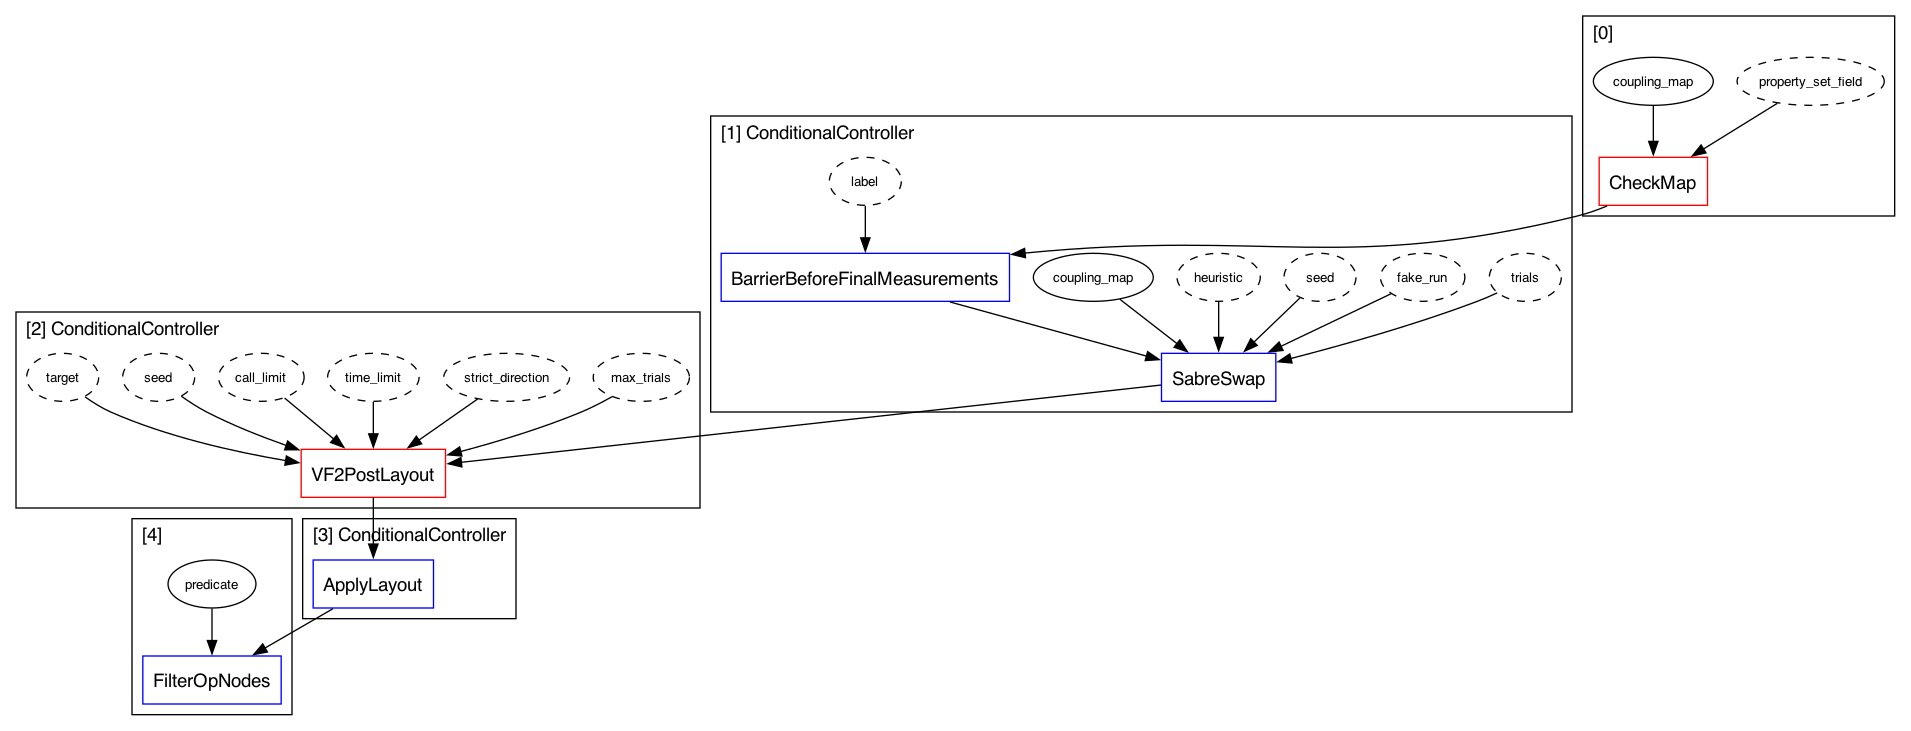

In [50]:
# # pass_manager_config = PassManagerConfig()
pass_manager_config = PassManagerConfig.from_backend(backend)
pass_manager_config.seed_transpiler = 12345
pass_manager_config.target = backend.target
pass_manager_config.coupling_map = updated_cm
# pass_manager_config

pm_3_upd = level_3_pass_manager(pass_manager_config)
# pm_3_upd.routing.draw().save("img1.png","PNG")
pm_3_upd.routing.draw()
# pass_manager_config.
# pass_manager_config.


# pm_3_exact.draw().save("pm_3.png","PNG")

In [38]:
pm_3_exact.stages

('init', 'layout', 'routing', 'translation', 'optimization', 'scheduling')

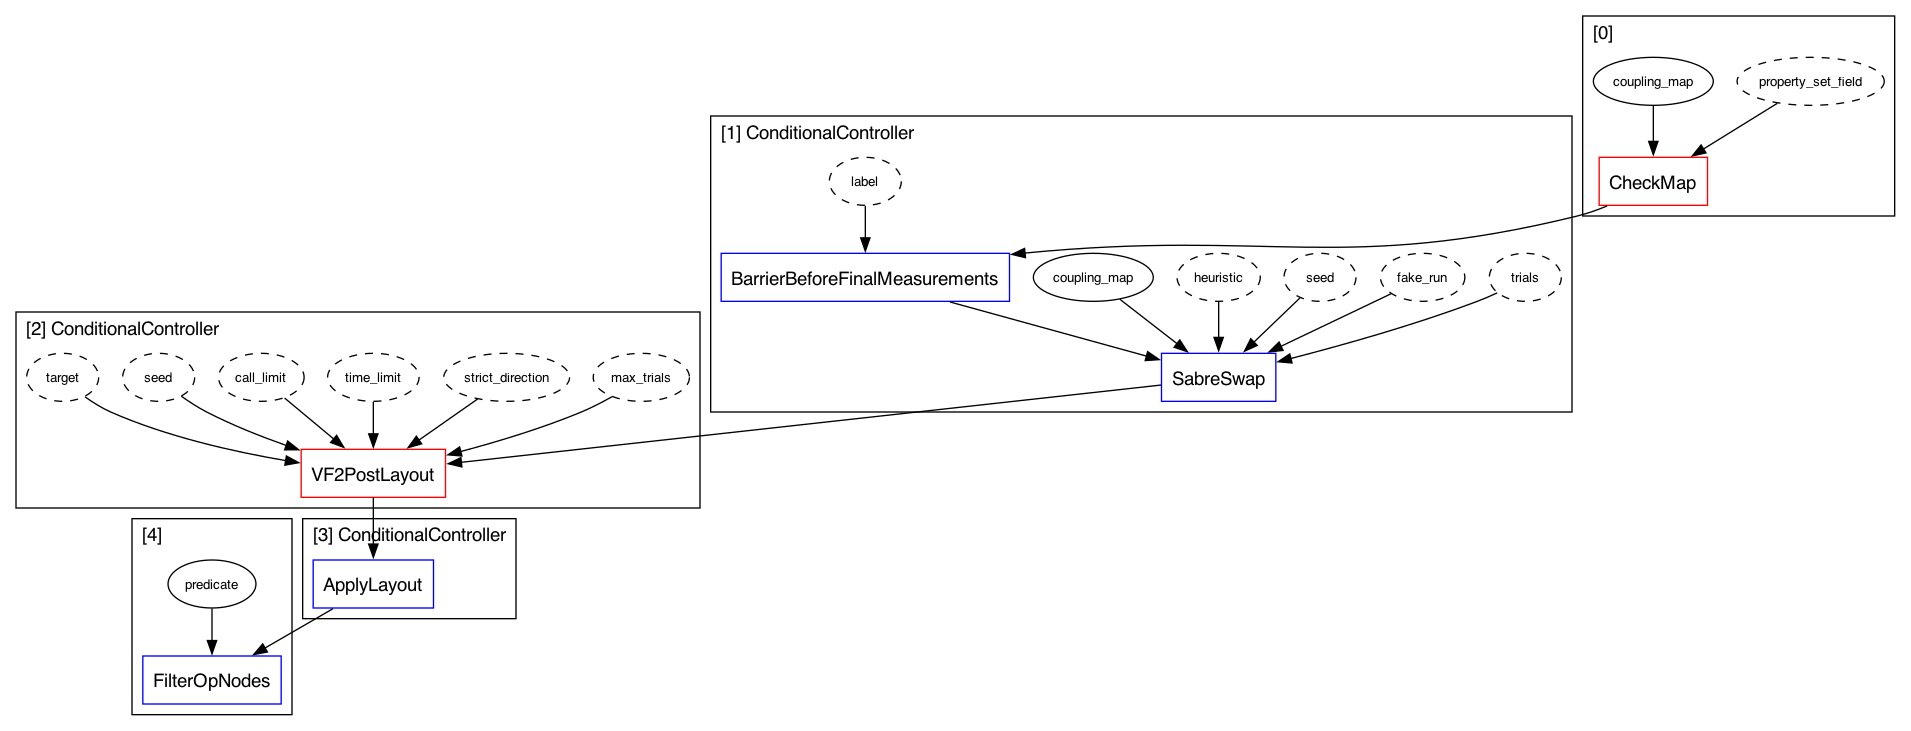

In [43]:
pm_3_exact.routing.draw()

In [33]:
pm_3_exact.routing.draw().save("pm_3_routing.png","PNG")
pm_1_exact.routing.draw().save("pm_1_routing.png","PNG")
pm_0_exact.routing.draw().save("pm_0_routing.png","PNG")

In [51]:
for x in pm_3_upd.routing:
    print(x)

In [392]:
# pm_3_upd.draw().save("img2.png","PNG")

In [53]:
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    SetLayout, ApplyLayout, FullAncillaAllocation, EnlargeWithAncilla,
    SabreSwap, RemoveResetInZeroState
)

# pm_sabre = SabreSwapPassManager().pass_manager(pass_manager_config, 3)
# tqc_3_upd = pm_sabre.run(qc)
# tqc_3_upd.draw("mpl", idle_wires=False, fold=-1)

In [56]:
# pm_na = generate_preset_pass_manager(
#     optimization_level=3, 
#     backend=backend, 
#     routing_method=sabre_na,
#     seed_transpiler=12345
# )

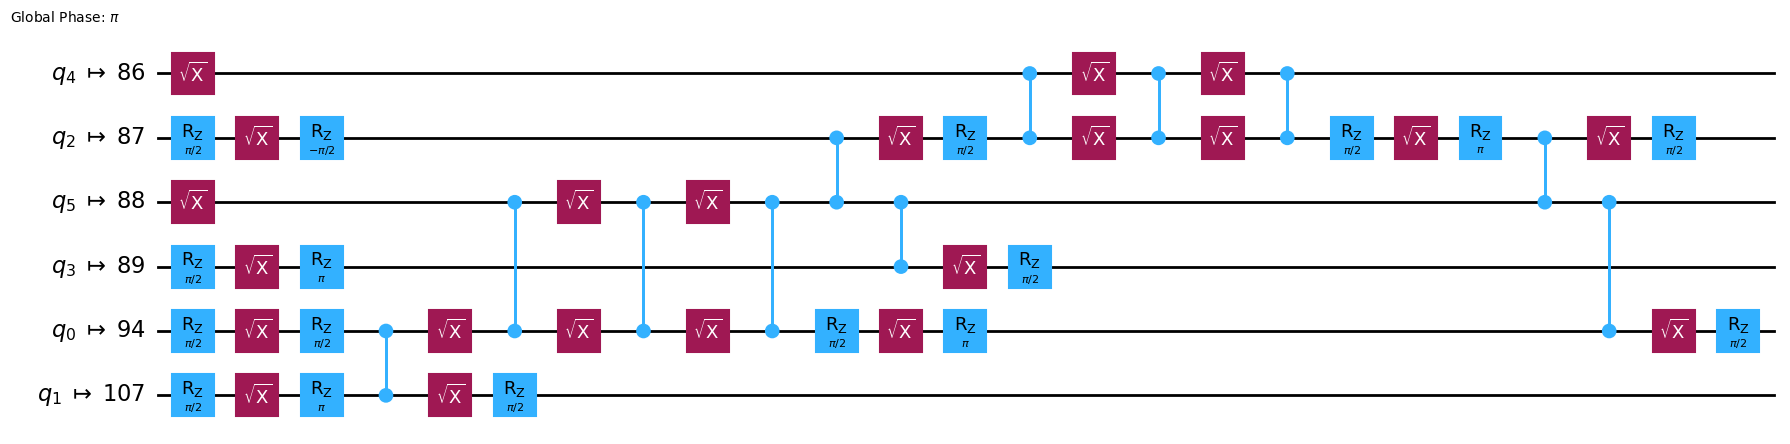

In [57]:
tqc_3_upd = pm_3_upd.run(qc)
tqc_3_upd.draw("mpl", idle_wires=False, fold=-1)

In [61]:
# dir(pm_3_upd.routing[0])

In [63]:
# pass_manager = PassManager()

# # Pre-routing layout
# pass_manager.append(SetLayout(backend.layout))
# pass_manager.append(FullAncillaAllocation(coupling))
# pass_manager.append(EnlargeWithAncilla())
# pass_manager.append(ApplyLayout())
# pass_manager.append(SabreSwap(updated_cm, heuristic='decay', seed=42))

In [96]:
sabre_na = SabreSwap(coupling_map=updated_cm, seed=12345)
# sabre_na.name = "Sabre Test"
sabre_na.name()
sabre_na.trials

4

In [86]:
# update distance matrix
tmp = cm._dist_matrix.copy()
tmp[0][1] = 30
tmp[0][2] = 8
tmp[0][126] = 200
tmp[41][53] = 200
tmp[53][41] = 200
tmp[72][81] = 200
tmp[81][72] = 200
tmp[82][83] = 100
tmp[83][82] = 100

cm._dist_matrix = tmp

In [98]:
sabre_na.dist_matrix = tmp
sabre_na.dist_matrix

array([[ 0., 30.,  8., ..., 25., 25., 25.],
       [ 1.,  0.,  1., ..., 26., 26., 26.],
       [ 2.,  1.,  0., ..., 27., 27., 27.],
       ...,
       [25., 26., 27., ...,  0.,  6., 10.],
       [25., 26., 27., ...,  6.,  0.,  6.],
       [25., 26., 27., ..., 10.,  6.,  0.]])

In [99]:
dag = circuit_to_dag(qc)

In [100]:
# sabre_na.run(dag)

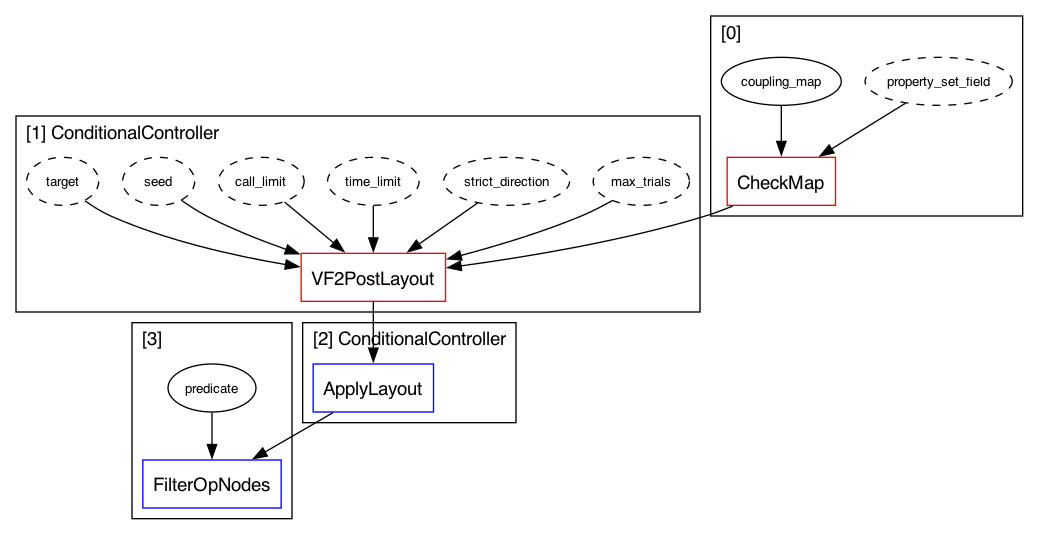

In [101]:
pm_3_upd = level_3_pass_manager(pass_manager_config)
pm_3_upd.routing.remove(1)
pm_3_upd.routing.draw()

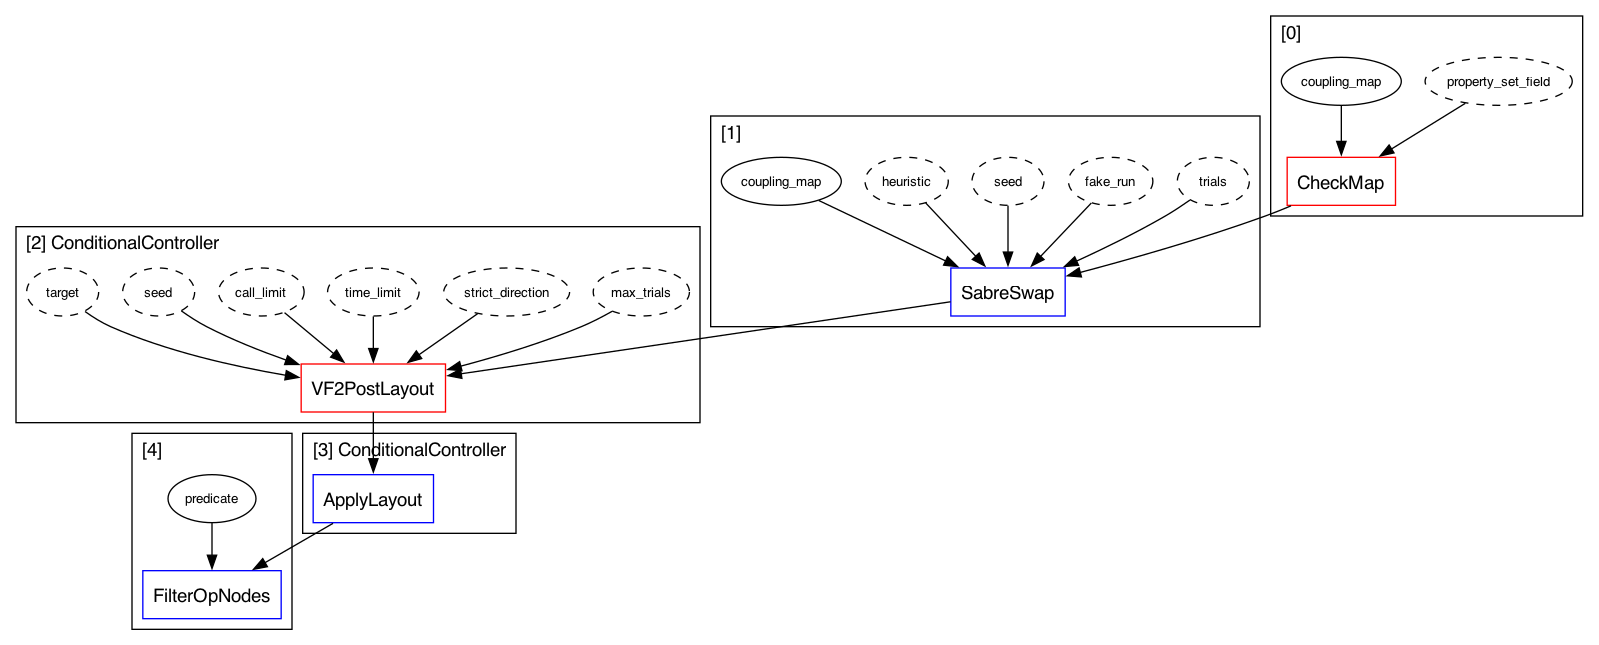

In [102]:
pm_3_upd.routing[0].append(sabre_na)
pm_3_upd.routing.draw()

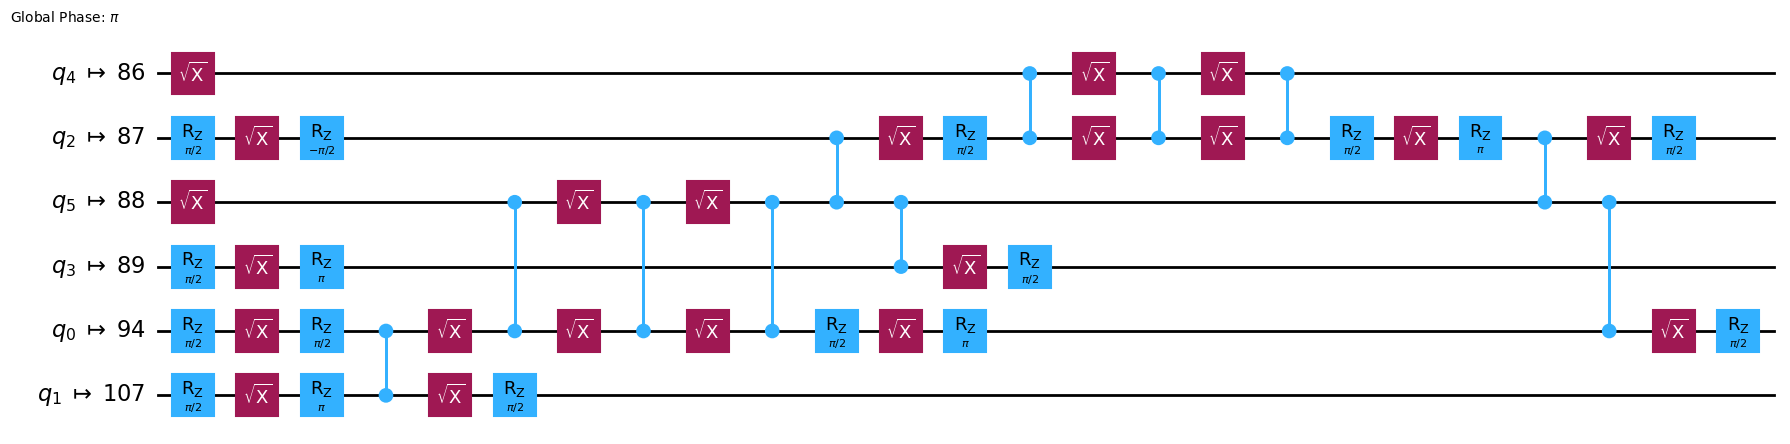

In [105]:
tqc_3_upd_na = pm_3_upd.run(qc)
tqc_3_upd_na.draw("mpl", idle_wires=False, fold=-1)

In [133]:
import copy
backend = service.backend("ibm_torino")
new_cm = copy.deepcopy(backend.coupling_map)


In [137]:
cm.distance_matrix

array([[ 0.,  1.,  2., ..., 25., 25., 25.],
       [ 1.,  0.,  1., ..., 26., 26., 26.],
       [ 2.,  1.,  0., ..., 27., 27., 27.],
       ...,
       [25., 26., 27., ...,  0.,  6., 10.],
       [25., 26., 27., ...,  6.,  0.,  6.],
       [25., 26., 27., ..., 10.,  6.,  0.]])

In [138]:
new_cm.distance_matrix

array([[ 0.,  1.,  2., ..., 25., 25., 25.],
       [ 1.,  0.,  1., ..., 26., 26., 26.],
       [ 2.,  1.,  0., ..., 27., 27., 27.],
       ...,
       [25., 26., 27., ...,  0.,  6., 10.],
       [25., 26., 27., ...,  6.,  0.,  6.],
       [25., 26., 27., ..., 10.,  6.,  0.]])

In [108]:
# update distance matrix
tmp = new_cm._dist_matrix.copy()
tmp[0][1] = 30
tmp[0][2] = 8
tmp[0][126] = 200
tmp[41][42] = 200
tmp[41][40] = 200
tmp[41][53] = 200
tmp[53][41] = 200
tmp[72][81] = 200
tmp[81][72] = 200
tmp[82][83] = 100
tmp[83][82] = 100
tmp[9][10] = 100
tmp[10][9] = 100
tmp[10][11] = 100
tmp[11][10] = 100
new_cm._dist_matrix = tmp

In [ ]:
# backend.coupling_map._dist_matrix = tmp
# backend.coupling_map._dist_matrix

array([[ 0., 30.,  8., ..., 25., 25., 25.],
       [ 1.,  0.,  1., ..., 26., 26., 26.],
       [ 2.,  1.,  0., ..., 27., 27., 27.],
       ...,
       [25., 26., 27., ...,  0.,  6., 10.],
       [25., 26., 27., ...,  6.,  0.,  6.],
       [25., 26., 27., ..., 10.,  6.,  0.]])

In [167]:
# refresh CM
new_cm._dist_matrix = None
new_cm.compute_distance_matrix()

# update distance matrix
tmp = new_cm._dist_matrix.copy()
tmp[0][1] = 100
tmp[1][0] = 100
tmp[10][11] = 100
tmp[11][10] = 100
tmp[86][87] = 100
tmp[87][86] = 100
tmp[85][86] = 100
tmp[86][85] = 100
tmp[87][88] = 100
tmp[88][87] = 100

new_cm._dist_matrix = tmp

updated_cm = new_cm
updated_cm.distance_matrix



array([[  0., 100.,   2., ...,  25.,  25.,  25.],
       [100.,   0.,   1., ...,  26.,  26.,  26.],
       [  2.,   1.,   0., ...,  27.,  27.,  27.],
       ...,
       [ 25.,  26.,  27., ...,   0.,   6.,  10.],
       [ 25.,  26.,  27., ...,   6.,   0.,   6.],
       [ 25.,  26.,  27., ...,  10.,   6.,   0.]])

In [168]:
from qiskit.transpiler.target import Target

In [169]:
conf = backend.configuration()
conf.coupling_map = new_cm

In [170]:
# print(dir(conf))

In [171]:
target = Target.from_configuration(
            basis_gates=conf.basis_gates,
            num_qubits=backend.num_qubits if backend is not None else None,
            coupling_map=updated_cm,
            instruction_durations=backend.instruction_durations,
            concurrent_measurements=(
                backend.target.concurrent_measurements if backend is not None else None
            ),
            dt=conf.dt,
        )



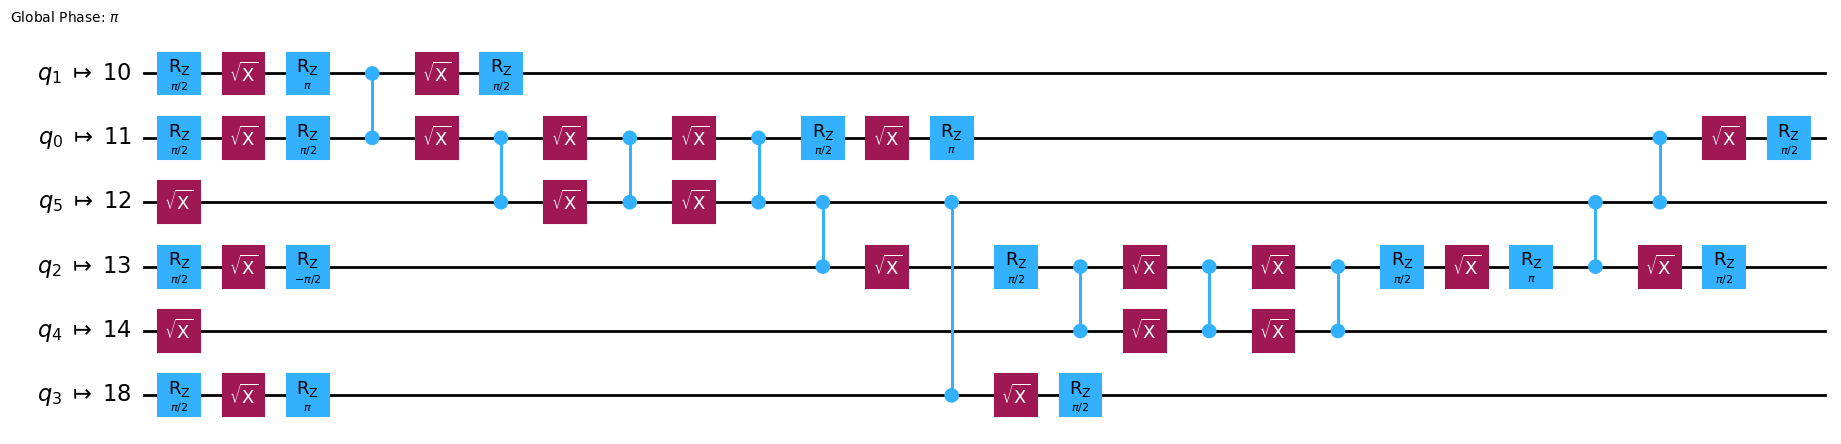

In [172]:
pm_3_new_na = generate_preset_pass_manager(
    optimization_level=3, 
    seed_transpiler=12345,
    backend=backend,
    coupling_map = updated_cm,
    # target=target,
)

pm_3_new_na.run(qc).draw("mpl", idle_wires=False, fold=-1)

In [ ]:
from qiskit import transpile
from qiskit.transpiler import CouplingMap, Target, InstructionProperties
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeTorino # Using fake backend for reproducibility
import copy

# 1. Setup Backend (Using FakeTorino for demonstration, swap with real service for production)
# service = QiskitRuntimeService()
backend = service.backend("ibm_torino")
# backend = FakeTorino()

print(f"Original qubit count: {backend.num_qubits}")


In [189]:

# 2. Create a fresh Target from the backend
# We copy the target so we don't mess up the original backend object
target = copy.deepcopy(backend.target)

# 3. Define the edges you want to penalize (make 'expensive')
# These are the pairs you tried to set distance=100 for
penalized_edges = [
    (0, 1), (1, 0),
    (10, 11), (11, 10),
    (86, 87), (87, 86),
    # (85, 86), (86, 85),
    # (87, 88), (88, 87)
]

print("Penalizing edges in Target...")

# 4. Modify the Target to make these edges 'noisy'
# SabreLayout (Noise Aware) looks at the error rate of the 2-qubit gates (usually ECR or CZ)
# operations = target.operation_names_for_qargs(None) # Get all operations
operations = target.operation_names

penalty_error = 1.0  # 100% error rate ensures Sabre avoids it like the plague
penalty_duration = 1e-4 # Optional: Make it slow too

for inst_name in operations:
    # We only care about 2-qubit gates (like 'ecr', 'cz', 'cx')
    if inst_name in ['measure', 'reset', 'delay']: 
        continue
        
    # Get the instruction object from the target
    instruction_op = target.operation_from_name(inst_name)
    
    # Check if this instruction works on 2 qubits
    if instruction_op.num_qubits == 2:
        # Iterate over the penalized edges
        for qubits in penalized_edges:
            # Check if this instruction is defined for these specific qubits in the target
            if qubits in target[inst_name]:
                print(f"  - Penalizing {inst_name} on {qubits}")
                
                # Get current properties to preserve duration if needed, or overwrite
                old_props = target[inst_name][qubits]
                
                # Create new properties with high error
                new_props = InstructionProperties(
                    duration=old_props.duration, # Keep original duration or increase it
                    error=penalty_error,         # SET HIGH ERROR
                )

                print(old_props, new_props)
                
                # Update the target
                target[inst_name][qubits] = new_props

# 5. Generate the Preset Pass Manager
# Optimization Level 3 automatically selects SabreLayout and SabreSwap.
# By passing our modified 'target', Sabre becomes "Noise Aware" of our penalties.
pm_3_new_na = generate_preset_pass_manager(
    optimization_level=3,
    target=target,  # This contains the connectivity AND the "noise" (penalties)
    seed_transpiler=12345
)

print("\nPass Manager generated successfully.")

Penalizing edges in Target...
  - Penalizing cz on (0, 1)
InstructionProperties(duration=6.8e-08, error=0.0017790793518438763) InstructionProperties(duration=6.8e-08, error=1.0)
  - Penalizing cz on (1, 0)
InstructionProperties(duration=6.8e-08, error=0.0017790793518438763) InstructionProperties(duration=6.8e-08, error=1.0)
  - Penalizing cz on (10, 11)
InstructionProperties(duration=6.8e-08, error=0.003533782509790695) InstructionProperties(duration=6.8e-08, error=1.0)
  - Penalizing cz on (11, 10)
InstructionProperties(duration=6.8e-08, error=0.003533782509790695) InstructionProperties(duration=6.8e-08, error=1.0)
  - Penalizing cz on (86, 87)
InstructionProperties(duration=6.8e-08, error=0.0014730365127825218) InstructionProperties(duration=6.8e-08, error=1.0)
  - Penalizing cz on (87, 86)
InstructionProperties(duration=6.8e-08, error=0.0014730365127825218) InstructionProperties(duration=6.8e-08, error=1.0)

Pass Manager generated successfully.


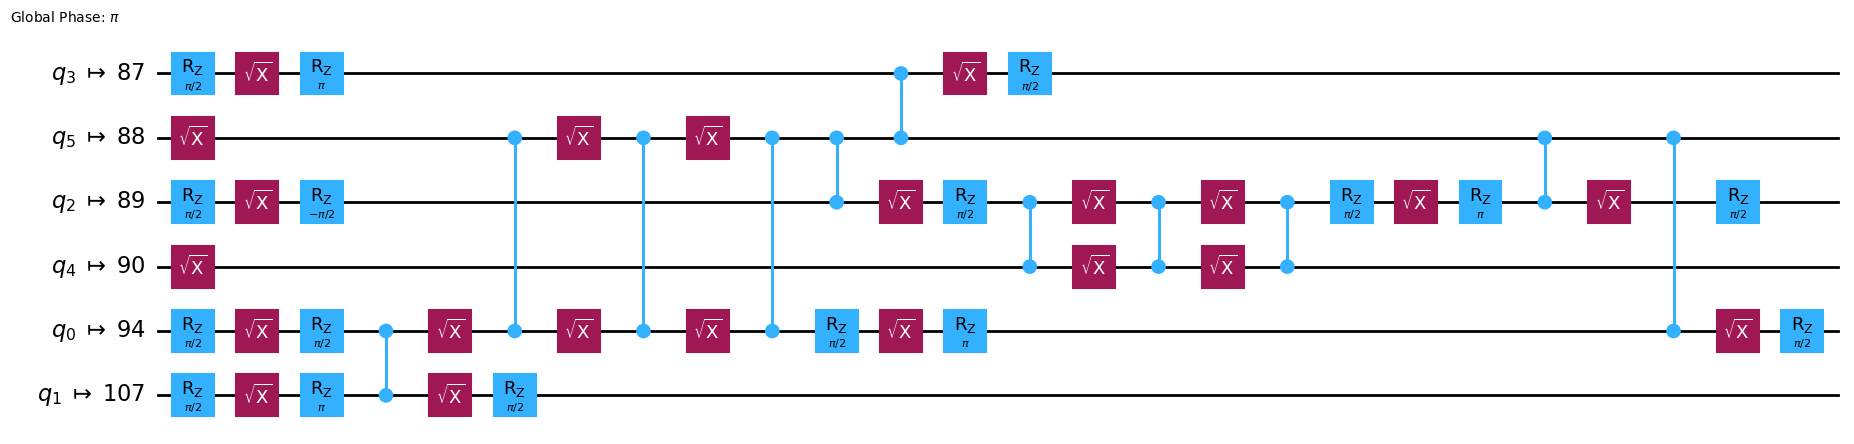

In [188]:
pm_3_new_na.run(qc).draw("mpl", idle_wires=False, fold=-1)

In [198]:
# Helper to find the best source instruction properties
def get_source_props(tgt, names, qubits):
    for name in names:
        if name in tgt.operation_names and qubits in tgt[name]:
            return tgt[name][qubits]
    return None

In [234]:
from qiskit import transpile
from qiskit.transpiler import CouplingMap, Target, InstructionProperties
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import HGate, CXGate, Measure
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeTorino # Using fake backend for reproducibility
import copy

# 1. Setup Backend (Using FakeTorino for demonstration, swap with real service for production)
# service = QiskitRuntimeService()
# backend = service.backend("ibm_torino")
# backend = FakeTorino()

print(f"Original qubit count: {backend.num_qubits}")

# 2. Create a fresh Target (Empty)
# We want to restrict the basis gates to H, CX, and Measure only.
# So we build a new target instead of copying the old one.

# target = Target(num_qubits=backend.num_qubits)
target = copy.deepcopy(backend.target)

# 3. Define the edges you want to penalize (make 'expensive')
penalized_edges = [
    (0, 1), (1, 0),
    (10, 11), (11, 10),
    (86, 87), (87, 86),
    # (85, 86), (86, 85),
    # (87, 88), (88, 87)
]

print("Constructing new Target with H, CX, Measure basis...")

# 4. Populate the new Target
# A. Map Single Qubit Gates (SX or X -> H)
# We copy error rates from the native single qubit gate (usually sx or x) to H
# src_1q_gates = ['sx', 'x', 'rz'] # Prioritize sx for error mapping
src_1q_gates = ['sx'] # Prioritize sx for error mapping
new_h_props = {}
for q in range(backend.num_qubits):
    props = get_source_props(backend.target, src_1q_gates, (q,))
    if props:
        new_h_props[(q,)] = props
target.add_instruction(HGate(), new_h_props)

# # B. Map Measure
# for q in range(backend.num_qubits):
#     props = get_source_props(backend.target, ['measure'], (q,))
#     if props:
#         target.add_instruction(Measure(), {(q,): props})

# C. Map 2-Qubit Gates (CZ or ECR -> CX) and Apply Penalties
# We look for 'cz' first, then 'ecr' to borrow error rates from.
src_2q_gates = ['cz', 'ecr'] 
found_2q_gate = None
for name in src_2q_gates:
    if name in backend.target.operation_names:
        found_2q_gate = name
        break

new_cx_props = {}
if found_2q_gate:
    print(f"Mapping properties from native '{found_2q_gate}' to 'cx'...")
    
    # Iterate over all defined edges for the native gate
    for qubits, old_props in backend.target[found_2q_gate].items():
        
        # Check if we need to penalize this specific edge
        if qubits in penalized_edges:
            print(f"  - Penalizing cx on {qubits} (mapped from {found_2q_gate})")
            new_props = InstructionProperties(
                duration=old_props.duration,
                error=1.0 # 100% error rate penalty
            )
            # target.add_instruction(CXGate(), {qubits: new_props})
            new_cx_props[qubits] = new_props
        else:
            # Copy original properties exactly
            # target.add_instruction(CXGate(), {qubits: old_props})
            new_cx_props[qubits] = old_props
else:
    print("Warning: No suitable 2-qubit gate found in backend to map from.")

target.add_instruction(CXGate(), new_cx_props)

# 5. Generate the Preset Pass Manager
# Optimization Level 3 automatically selects SabreLayout and SabreSwap.
# The transpiler will now strictly use H and CX because those are the only 
# gates defined in our 'target'.
pm_3_new_na_cx = generate_preset_pass_manager(
    optimization_level=3,
    target=target, 
    seed_transpiler=12345
)

print("\nPass Manager generated successfully.")



Original qubit count: 133
Constructing new Target with H, CX, Measure basis...
Mapping properties from native 'cz' to 'cx'...
  - Penalizing cx on (0, 1) (mapped from cz)
  - Penalizing cx on (1, 0) (mapped from cz)
  - Penalizing cx on (10, 11) (mapped from cz)
  - Penalizing cx on (11, 10) (mapped from cz)
  - Penalizing cx on (86, 87) (mapped from cz)
  - Penalizing cx on (87, 86) (mapped from cz)

Pass Manager generated successfully.


In [242]:
from qiskit import transpile
from qiskit.transpiler import CouplingMap, Target, InstructionProperties
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import HGate, CXGate, Measure
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeTorino # Using fake backend for reproducibility
import copy

def create_sabre_na_pm(backend, optimization_level, seed_transpiler, penalized_edges = []):

    target = copy.deepcopy(backend.target)

    # penalized_edges = [
    #     (0, 1), (1, 0),
    # ]

    src_1q_gates = ['sx'] # Prioritize sx for error mapping
    new_h_props = {}
    for q in range(backend.num_qubits):
        props = get_source_props(backend.target, src_1q_gates, (q,))
        if props:
            new_h_props[(q,)] = props
    target.add_instruction(HGate(), new_h_props)

    src_2q_gates = ['cz', 'ecr'] 
    found_2q_gate = None
    for name in src_2q_gates:
        if name in backend.target.operation_names:
            found_2q_gate = name
            break

    new_cx_props = {}
    if found_2q_gate:
        print(f"Mapping properties from native '{found_2q_gate}' to 'cx'...")
        
        # Iterate over all defined edges for the native gate
        for qubits, old_props in backend.target[found_2q_gate].items():
            
            # Check if we need to penalize this specific edge
            if qubits in penalized_edges:
                print(f"  - Penalizing cx on {qubits} (mapped from {found_2q_gate})")
                new_props = InstructionProperties(
                    duration=old_props.duration,
                    error=1.0 # 100% error rate penalty
                )
                # target.add_instruction(CXGate(), {qubits: new_props})
                new_cx_props[qubits] = new_props
            else:
                # Copy original properties exactly
                # target.add_instruction(CXGate(), {qubits: old_props})
                new_cx_props[qubits] = old_props
    else:
        print("Warning: No suitable 2-qubit gate found in backend to map from.")

    target.add_instruction(CXGate(), new_cx_props)

    pm_3_new_na = generate_preset_pass_manager(
        optimization_level=optimization_level,
        target=target, 
        seed_transpiler=seed_transpiler
    )

    return pm_3_new_na
    



In [243]:
pm_3_new_na_cx = create_sabre_na_pm(backend, 3, 12345)

Mapping properties from native 'cz' to 'cx'...


Output basis gates: OrderedDict([('cx', 9), ('h', 1)])


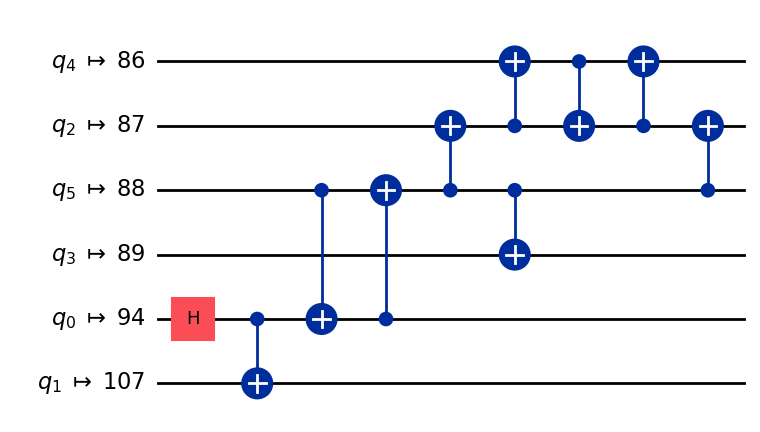

In [244]:
# --- Verification ---
# Let's create a dummy circuit that would theoretically use edge 0-1 
# and see if it avoids it.
transpiled_qc = pm_3_new_na_cx.run(qc)
print(f"Output basis gates: {transpiled_qc.count_ops()}")
transpiled_qc.draw("mpl", idle_wires=False, fold=-1)

In [225]:
target["h"]

{(132,): InstructionProperties(duration=3.2e-08, error=0.00028251724741110276)}